In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scientisttools import FAMD, MCA
# Gower distance + UMAP — nonlinear mixed‑datatype embedding
import gower

random_state = 1776

In [2]:
import scientisttools
dir(scientisttools.FAMD)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_validate_params',
 'fit',
 'fit_transform',
 'get_metadata_routing',
 'get_params',
 'set_output',
 'set_params',
 'transform']

In [3]:
df = pd.DataFrame({
    "Age": [45, 60, 30, 50],
    "BMI": [22.5, 31.2, 27.8, 29.1],
    "Sex": ["M", "F", "F", "M"],
    "Diagnosis": ["COPD", "ILD", "COPD", "ARDS"]
})
df

,Age,BMI,Sex,Diagnosis
0,45,22.5,M,COPD
1,60,31.2,F,ILD
2,30,27.8,F,COPD
3,50,29.1,M,ARDS


In [4]:
famd = FAMD(n_components=2)
famd.fit(df)

# Component scores
scores = famd.transform(df)
print(scores.head())

      Dim.1     Dim.2
0 -1.779619  0.212923
1  2.501292 -0.526252
2 -0.872294 -1.611119
3  0.150621  1.924448


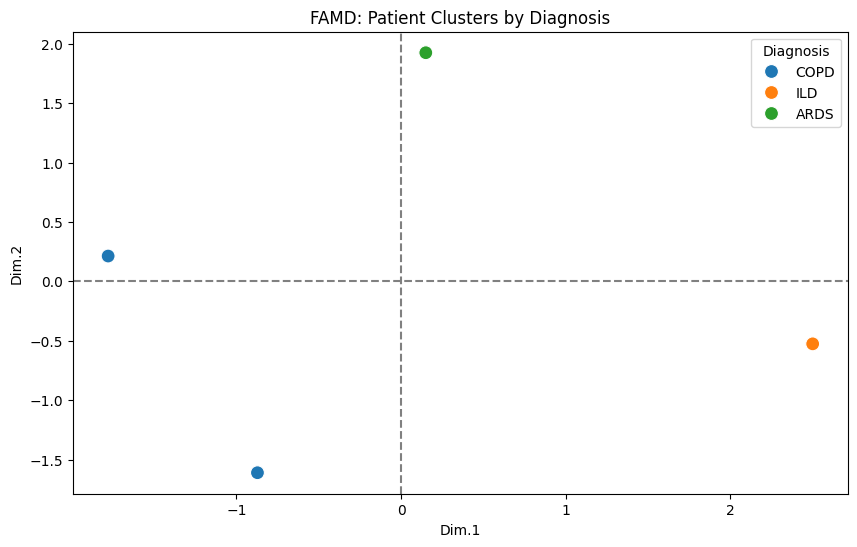

In [5]:
# Convert scores to a DataFrame for easier plotting
scores_df = scores.copy()
scores_df['Diagnosis'] = df['Diagnosis']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scores_df, x='Dim.1', y='Dim.2', hue='Diagnosis', s=100)
plt.title("FAMD: Patient Clusters by Diagnosis")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

In [6]:
# distance
gower_dist = gower.gower_matrix(df)

In [7]:
# Feed into UMAP
import umap

umap_model = umap.UMAP(metric="precomputed", 
                       n_neighbors=3, 
                       min_dist=0.1,
                      random_state= random_state,
                      n_jobs=1)
embedding1 = umap_model.fit_transform(gower_dist)

print(embedding1)

/opt/homebrew/Caskroom/miniconda/base/envs/stools/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable


[[-3.2281246 -3.2778528]
 [-3.5946689 -1.8548145]
 [-4.1651826 -2.6922662]
 [-2.6431868 -2.454892 ]]


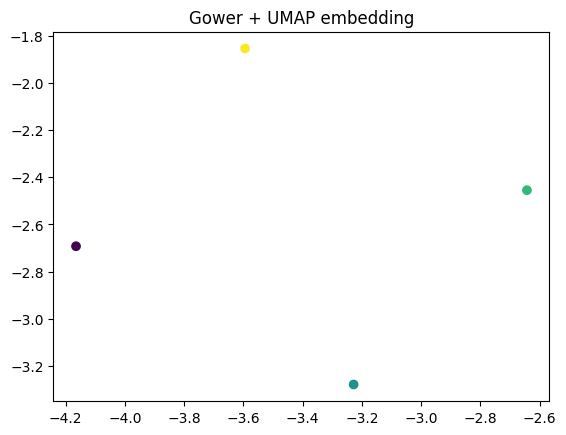

In [8]:
plt.scatter(embedding1[:,0], embedding1[:,1], c=df["Age"], cmap="viridis")
plt.title("Gower + UMAP embedding")
plt.show()

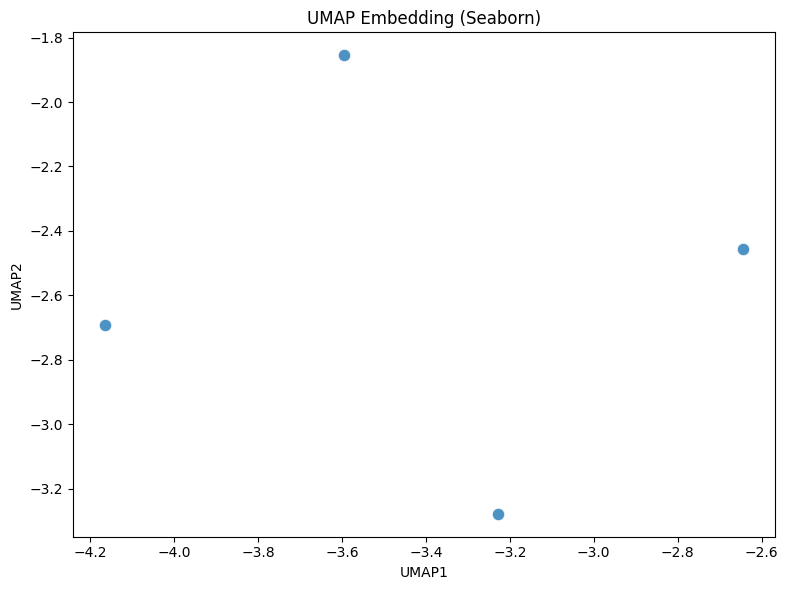

In [9]:
# Convert embedding to a DataFrame
df_umap = pd.DataFrame(embedding1, columns=["UMAP1", "UMAP2"])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_umap,
    x="UMAP1",
    y="UMAP2",
    s=80,
    alpha=0.8
)

plt.title("UMAP Embedding (Seaborn)")
plt.tight_layout()
plt.show()


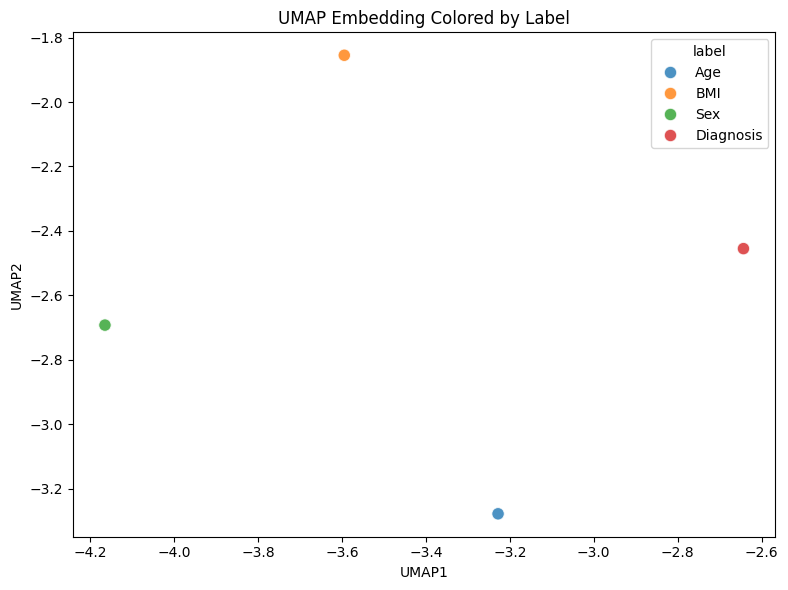

In [10]:
df_umap["label"] = df.columns.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_umap,
    x="UMAP1",
    y="UMAP2",
    hue="label",
    palette="tab10",
    s=80,
    alpha=0.8
)
plt.title("UMAP Embedding Colored by Label")
plt.tight_layout()
plt.show()


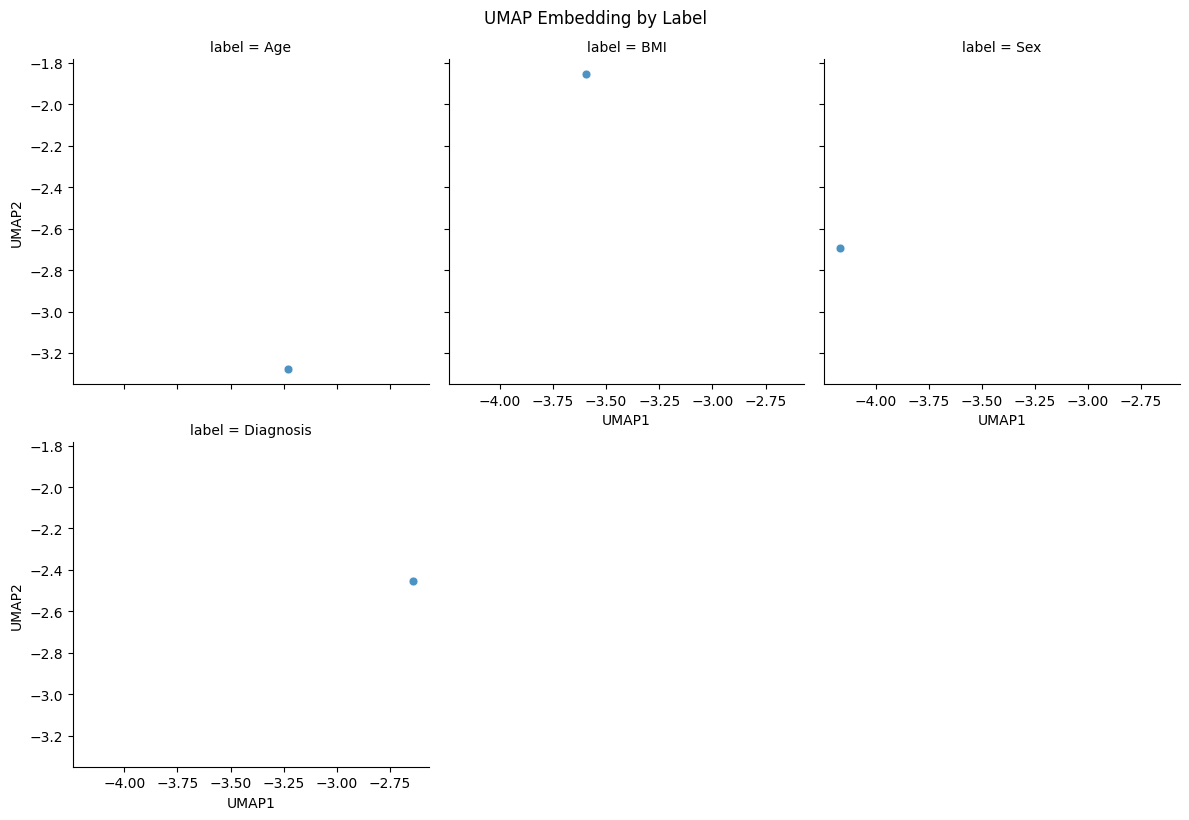

In [11]:
g = sns.FacetGrid(df_umap, col="label", col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x="UMAP1", y="UMAP2", s=40, alpha=0.8)
g.fig.suptitle("UMAP Embedding by Label", y=1.02)
plt.show()


In [12]:
# HDBSCAN — the best default for UMAP embeddings
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,            # minimum number of points required to form a cluster
    min_samples=1,                 # strict the density requirement 
    cluster_selection_epsilon=0.0, # optional relaxation parameter (0: Don’t relax cluster boundaries at all.)
    cluster_selection_method="eom" # Excess of Mass (default)
)

labels = clusterer.fit_predict(embedding1)
print(labels)

[0 1 1 0]


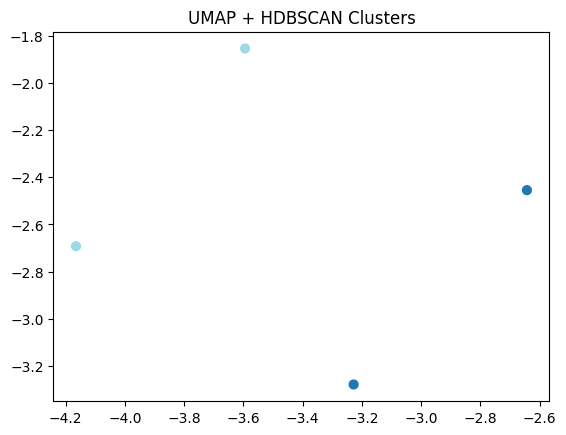

In [13]:
plt.scatter(
    embedding1[:,0], embedding1[:,1],
    c=labels, cmap="tab20", s=40
)
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

In [14]:
# K‑Means — if your embedding is roughly spherical
from sklearn.cluster import KMeans

k = 4  # choose based on silhouette or elbow
kmeans = KMeans(n_clusters=k, n_init=20)
labels = kmeans.fit_predict(embedding1)

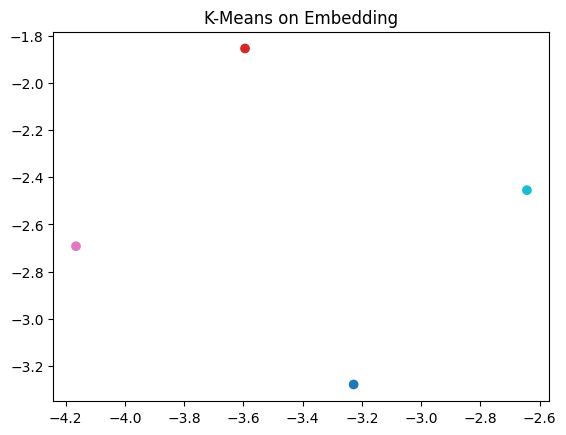

In [15]:
plt.scatter(embedding1[:,0], embedding1[:,1], c=labels, cmap="tab10")
plt.title("K-Means on Embedding")
plt.show()

In [16]:
# Agglomerative (Hierarchical) Clustering
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels = model.fit_predict(embedding1)
print(labels)

[1 0 0 1]


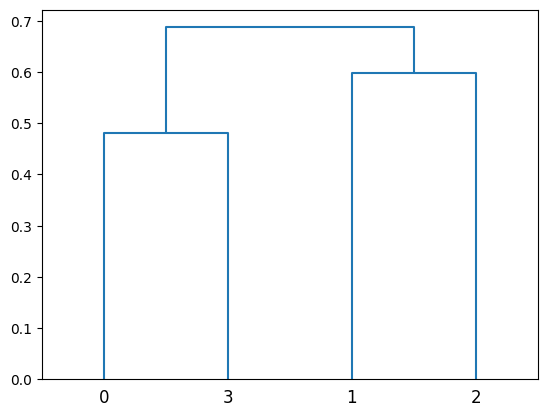

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

dist_condensed = squareform(gower_dist)
Z = linkage(dist_condensed, method="average")

dendrogram(Z)
plt.show()

In [18]:
# Cluster validation
from sklearn.metrics import silhouette_score
# Silhouette score
sil = silhouette_score(embedding1, labels)
print("Silhouette:", sil)

Silhouette: 0.22768455743789673


In [19]:
# Davies–Bouldin
from sklearn.metrics import davies_bouldin_score

db = davies_bouldin_score(embedding1, labels)
print("DB index:", db)

DB index: 0.9072124486772886


In [20]:
unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique, counts))

{0: 2, 1: 2}

In [21]:
 # Compute cluster centroids in the original feature space

def compute_centroids(df, labels):
    df = df.copy()
    df["cluster"] = labels

    centroids = {}

    for cluster_id, group in df.groupby("cluster"):
        summary = {}

        for col in df.columns:
            if col == "cluster":
                continue

            if pd.api.types.is_numeric_dtype(df[col]):
                summary[col] = group[col].mean()

            elif pd.api.types.is_bool_dtype(df[col]):
                summary[col] = group[col].mean()

            else:
                # categorical / string / mixed
                summary[col] = group[col].mode(dropna=True).iloc[0]

        centroids[cluster_id] = summary

    return pd.DataFrame(centroids).T

In [22]:
centroids = compute_centroids(df, labels)
centroids

,Age,BMI,Sex,Diagnosis
0,45.0,29.5,F,COPD
1,47.5,25.8,M,ARDS


In [23]:
# Build cluster interpretation tables
def cluster_summary(df, labels):
    df = df.copy()
    df["cluster"] = labels
    clusters = sorted(df["cluster"].unique())

    tables = {}

    for col in df.columns:
        if col == "cluster":
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            table = df.groupby("cluster")[col].agg(["mean", "std", "median", "min", "max"])
        
        else:
            table = (
                df.groupby("cluster")[col]
                  .value_counts(normalize=True)
                  .rename("pct")
                  .mul(100)
                  .round(1)
                  .unstack(fill_value=0)
            )

        tables[col] = table

    return tables

In [24]:
tables = cluster_summary(df, labels)
tables['Age']

,mean,std,median,min,max
cluster,,,,,
0,45.0,21.213203,45.0,30,60
1,47.5,3.535534,47.5,45,50


In [25]:
# Compute pairwise cluster distances
from scipy.spatial.distance import pdist, squareform

# Euclidean
numeric_centroids = centroids.select_dtypes(include="number")
dist_matrix = pd.DataFrame(
    squareform(pdist(numeric_centroids, metric="euclidean")),
    index=numeric_centroids.index,
    columns=numeric_centroids.index
)

In [26]:
dist_matrix

,0,1
0,0.0,0.0
1,0.0,0.0


In [27]:
# Gower (mixed datatypes)
dist_matrix = pd.DataFrame(
    gower.gower_matrix(centroids),
    index=centroids.index,
    columns=centroids.index
)

In [28]:
dist_matrix

,0,1
0,0.0,1.0
1,1.0,0.0


In [29]:
# Evaluate cluster stability across embeddings

from sklearn.metrics import adjusted_rand_score

# Use Adjusted Rand Index (ARI)
def compare_clusterings(label_dict):
    # label_dict = {"PCA": labels_pca, "UMAP": labels_umap, ...}
    methods = list(label_dict.keys())
    n = len(methods)

    ari_matrix = pd.DataFrame(index=methods, columns=methods)

    for i in range(n):
        for j in range(n):
            ari_matrix.iloc[i, j] = adjusted_rand_score(
                label_dict[methods[i]],
                label_dict[methods[j]]
            )

    return ari_matrix.astype(float)

In [30]:
# label_dict = {
#     "PCA": labels_pca,
#     "PCoA": labels_pcoa,
#     "MDS": labels_mds,
#     "UMAP": labels_umap,
#     "GowerUMAP": labels_gumap
# }

# stability = compare_clusterings(label_dict)
# stability

# ARI > 0.75 → highly stable
# 0.4–0.75 → moderately stable
# < 0.4 → unstable / embedding‑dependent

In [31]:
# Mixed‑Datatype Clustering Pipeline
class MixedClusteringPipeline:
    """
    A reusable, end-to-end pipeline for:
    - mixed-datatype dimensionality reduction
    - clustering
    - centroid computation
    - cluster interpretation
    - pairwise cluster distances
    - stability across embeddings
    """

    def __init__(
        self,
        embedding_methods=("FAMD", "UMAP"),
        cluster_method="HDBSCAN",
        n_components=2,
        random_state=42,
        n_jobs=1,
        n_neighbors=15,
        n_init=20,
        n_clusters=2,
    ):
        self.embedding_methods = embedding_methods
        self.cluster_method = cluster_method
        self.n_components = n_components
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.n_neighbors = n_neighbors
        self.n_init = n_init
        self.n_clusters = n_clusters

        self.embeddings = {}
        self.cluster_labels = {}
        self.centroids = None
        self.interpretation_tables = None
        self.distance_matrix = None
        self.stability_matrix = None

    # ---------------------------------------------------------
    # 1. Dimensionality Reduction
    # ---------------------------------------------------------
    def compute_embeddings(self, dataframe):
        from umap import UMAP

        for method in self.embedding_methods:

            if method == "FAMD":
                famd = FAMD(n_components=self.n_components)
                famd.fit(dataframe)
                self.embeddings["FAMD"] = np.asarray(famd.transform(dataframe))

            elif method == "UMAP":
                gower_dist = gower.gower_matrix(dataframe)
                umap_model = UMAP(
                    metric="precomputed",
                    n_neighbors=self.n_neighbors,
                    min_dist=0.1,
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                )
                self.embeddings["UMAP"] = umap_model.fit_transform(gower_dist)

            else:
                raise ValueError(f"Unknown embedding method: {method}")

        return self.embeddings

    # ---------------------------------------------------------
    # 2. Clustering
    # ---------------------------------------------------------
    def cluster(self):
        for name, emb in self.embeddings.items():

            if self.cluster_method == "HDBSCAN":
                model = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
                labels = model.fit_predict(emb)

            elif self.cluster_method == "KMeans":
                model = KMeans(n_clusters=self.n_clusters, n_init=self.n_init)
                labels = model.fit_predict(emb)

            elif self.cluster_method == "Agglomerative":
                model = AgglomerativeClustering(n_clusters=self.n_clusters)
                labels = model.fit_predict(emb)

            else:
                raise ValueError(f"Unknown cluster method: {self.cluster_method}")

            self.cluster_labels[name] = labels

        return self.cluster_labels

    # ---------------------------------------------------------
    # 3. Centroids in Original Feature Space
    # ---------------------------------------------------------
    def compute_centroids(self, dataframe, labels):
        dataframe = dataframe.copy()
        dataframe["cluster"] = labels

        centroids = {}

        for cid, group in dataframe.groupby("cluster"):
            summary = {}

            for col in dataframe.columns:
                if col == "cluster":
                    continue

                if pd.api.types.is_numeric_dtype(dataframe[col]):
                    summary[col] = group[col].mean()

                else:
                    summary[col] = group[col].mode(dropna=True).iloc[0]

            centroids[cid] = summary

        self.centroids = pd.DataFrame(centroids).T
        return self.centroids

    # ---------------------------------------------------------
    # 4. Interpretation Tables
    # ---------------------------------------------------------
    def build_interpretation_tables(self, dataframe, labels):
        dataframe = dataframe.copy()
        dataframe["cluster"] = labels

        tables = {}

        for col in dataframe.columns:
            if col == "cluster":
                continue

            if pd.api.types.is_numeric_dtype(dataframe[col]):
                table = dataframe.groupby("cluster")[col].agg(
                    ["mean", "std", "median", "min", "max"]
                )
            else:
                table = (
                    dataframe.groupby("cluster")[col]
                    .value_counts(normalize=True)
                    .rename("pct")
                    .mul(100)
                    .round(1)
                    .unstack(fill_value=0)
                )

            tables[col] = table

        self.interpretation_tables = tables
        return tables

    # ---------------------------------------------------------
    # 5. Pairwise Cluster Distances
    # ---------------------------------------------------------
    def compute_pairwise_distances(self):
        if self.centroids is None:
            raise ValueError("Compute centroids first.")

        self.distance_matrix = pd.DataFrame(
            squareform(pdist(self.centroids.select_dtypes(include="number"))),
            index=self.centroids.index,
            columns=self.centroids.index,
        )
        return self.distance_matrix

    # ---------------------------------------------------------
    # 6. Stability Across Embeddings
    # ---------------------------------------------------------
    def compute_stability(self):
        methods = list(self.cluster_labels.keys())
        n = len(methods)

        stability = pd.DataFrame(index=methods, columns=methods)

        for i in range(n):
            for j in range(n):
                stability.iloc[i, j] = adjusted_rand_score(
                    self.cluster_labels[methods[i]],
                    self.cluster_labels[methods[j]],
                )

        self.stability_matrix = stability.astype(float)
        return self.stability_matrix


In [32]:
import numpy as np
import pandas as pd

from scipy.spatial.distance import pdist, squareform
from scipy.stats import kruskal

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from umap import UMAP
import gower
import hdbscan

# FAMD
from scientisttools import FAMD

# K-Medoids
from sklearn_extra.cluster import KMedoids


# Mixed‑Datatype Clustering Pipeline
class MixedClusteringPipeline:
    """
    End-to-end mixed-data clustering pipeline:
    - preprocessing
    - embeddings (FAMD / Gower+UMAP)
    - clustering (HDBSCAN / KMeans / Agglomerative / KMedoids)
    - cluster prototypes
    - interpretation tables
    - pairwise cluster distances
    - stability across embeddings
    - cluster quality metrics
    - survival validation
    - phenotype summaries
    """

    def __init__(
        self,
        embedding_methods=("FAMD", "UMAP"),
        cluster_method="HDBSCAN",
        n_components=2,
        random_state=42,
        n_jobs=1,
        n_neighbors=15,
        n_init=20,
        n_clusters=2,
        min_cluster_size=30,
        min_samples=5,
        drop_noise=True,
        verbose=True,
    ):
        self.embedding_methods = embedding_methods
        self.cluster_method = cluster_method
        self.n_components = n_components
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.n_neighbors = n_neighbors
        self.n_init = n_init
        self.n_clusters = n_clusters
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.drop_noise = drop_noise
        self.verbose = verbose

        self.cleaned_df = None
        self.embeddings = {}
        self.distance_matrices = {}
        self.cluster_labels = {}
        self.cluster_models = {}
        self.prototypes = {}
        self.interpretation_tables = {}
        self.distance_matrix = {}
        self.stability_matrix = None
        self.quality_metrics = {}
        self.survival_results = {}
        self.phenotype_tables = {}

    # ---------------------------------------------------------
    # 0. Preprocessing
    # ---------------------------------------------------------
    def preprocess(self, dataframe, id_cols=None):
        df = dataframe.copy()

        if id_cols is None:
            id_cols = []

        # Drop user-specified ID columns
        df = df.drop(columns=[c for c in id_cols if c in df.columns], errors="ignore")

        # Drop all-missing columns
        all_missing = df.columns[df.isna().all()].tolist()
        if all_missing and self.verbose:
            print(f"Dropping all-missing columns: {all_missing}")
        df = df.drop(columns=all_missing)

        # Drop constant columns
        constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
        if constant_cols and self.verbose:
            print(f"Dropping constant columns: {constant_cols}")
        df = df.drop(columns=constant_cols)

        # Convert object columns to category for cleaner mixed-data handling
        for col in df.columns:
            if df[col].dtype == "object":
                df[col] = df[col].astype("category")

        self.cleaned_df = df
        return self.cleaned_df

    # ---------------------------------------------------------
    # 1. Dimensionality Reduction
    # ---------------------------------------------------------
    def compute_embeddings(self, dataframe):
        df = dataframe.copy()

        for method in self.embedding_methods:

            if method == "FAMD":
                famd = FAMD(
                    n_components=self.n_components,
                    random_state=self.random_state
                )
                famd = famd.fit(df)
                emb = famd.transform(df)
                self.embeddings["FAMD"] = np.asarray(emb)

            elif method == "UMAP":
                gower_dist = gower.gower_matrix(df)
                self.distance_matrices["Gower"] = gower_dist

                umap_model = UMAP(
                    metric="precomputed",
                    n_neighbors=self.n_neighbors,
                    min_dist=0.1,
                    n_components=self.n_components,
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                )
                emb = umap_model.fit_transform(gower_dist)
                self.embeddings["UMAP"] = np.asarray(emb)

            else:
                raise ValueError(f"Unknown embedding method: {method}")

        return self.embeddings

    # ---------------------------------------------------------
    # 2. Clustering
    # ---------------------------------------------------------
    def cluster(self):
        for name, emb in self.embeddings.items():

            if self.cluster_method == "HDBSCAN":
                model = hdbscan.HDBSCAN(
                    min_cluster_size=self.min_cluster_size,
                    min_samples=self.min_samples,
                )
                labels = model.fit_predict(emb)

            elif self.cluster_method == "KMeans":
                model = KMeans(
                    n_clusters=self.n_clusters,
                    n_init=self.n_init,
                    random_state=self.random_state,
                )
                labels = model.fit_predict(emb)

            elif self.cluster_method == "Agglomerative":
                model = AgglomerativeClustering(n_clusters=self.n_clusters)
                labels = model.fit_predict(emb)

            elif self.cluster_method == "KMedoids":
                model = KMedoids(
                    n_clusters=self.n_clusters,
                    metric="precomputed",
                    init="random",          # required for precomputed distances
                    # metric="euclidean",
                    # init="k-medoids++",
                    random_state=self.random_state,
                )
                labels = model.fit_predict(emb)

            else:
                raise ValueError(f"Unknown cluster method: {self.cluster_method}")

            self.cluster_labels[name] = labels
            self.cluster_models[name] = model

        return self.cluster_labels

    # ---------------------------------------------------------
    # 2B. Direct Gower + KMedoids (recommended for mixed data)
    # ---------------------------------------------------------
    def cluster_gower_kmedoids(self, dataframe, n_clusters=None):
        """
        Clusters directly on Gower distance matrix using KMedoids.
        This is often one of the best options for mixed datatype clustering.
        """
        df = dataframe.copy()
        if n_clusters is None:
            n_clusters = self.n_clusters

        gower_dist = gower.gower_matrix(df)
        self.distance_matrices["Gower"] = gower_dist

        model = KMedoids(
            n_clusters=n_clusters,
            metric="precomputed",
            init="random",          # required for precomputed distances
            random_state=self.random_state,
        )
        labels = model.fit_predict(gower_dist)

        self.cluster_labels["Gower_KMedoids"] = labels
        self.cluster_models["Gower_KMedoids"] = model

        return labels

    # ---------------------------------------------------------
    # 3. Prototypes / Representative Summaries
    # ---------------------------------------------------------
    def compute_prototypes(self, dataframe, labels, include_noise=False):
        df = dataframe.copy()
        df["cluster"] = labels

        if self.drop_noise and not include_noise:
            df = df[df["cluster"] != -1]

        prototypes = {}

        for cid, group in df.groupby("cluster"):
            summary = {}

            for col in dataframe.columns:
                if pd.api.types.is_numeric_dtype(dataframe[col]):
                    summary[f"{col}__mean"] = group[col].mean()
                    summary[f"{col}__median"] = group[col].median()
                else:
                    vc = group[col].value_counts(dropna=False, normalize=True)
                    if len(vc) > 0:
                        top_cat = vc.index[0]
                        top_pct = round(vc.iloc[0] * 100, 1)
                        summary[f"{col}__mode"] = top_cat
                        summary[f"{col}__mode_pct"] = top_pct
                    else:
                        summary[f"{col}__mode"] = np.nan
                        summary[f"{col}__mode_pct"] = np.nan

            prototypes[cid] = summary

        self.prototypes["latest"] = pd.DataFrame(prototypes).T
        return self.prototypes["latest"]

    # ---------------------------------------------------------
    # 4. Interpretation Tables
    # ---------------------------------------------------------
    def build_interpretation_tables(self, dataframe, labels, include_noise=False):
        df = dataframe.copy()
        df["cluster"] = labels

        if self.drop_noise and not include_noise:
            df = df[df["cluster"] != -1]

        tables = {}

        for col in dataframe.columns:
            if pd.api.types.is_numeric_dtype(dataframe[col]):
                table = df.groupby("cluster")[col].agg(
                    ["count", "mean", "std", "median", "min", "max"]
                )
            else:
                table = (
                    df.groupby("cluster")[col]
                    .value_counts(normalize=True)
                    .rename("pct")
                    .mul(100)
                    .round(1)
                    .unstack(fill_value=0)
                )

            tables[col] = table

        self.interpretation_tables["latest"] = tables
        return tables

    # ---------------------------------------------------------
    # 5. Pairwise Cluster Distances in Embedding Space
    # ---------------------------------------------------------
    def compute_pairwise_distances(self, embedding_name):
        if embedding_name not in self.embeddings:
            raise ValueError(f"{embedding_name} not found in embeddings.")

        emb = self.embeddings[embedding_name]
        labels = self.cluster_labels[embedding_name]

        valid = labels != -1 if self.drop_noise else np.ones(len(labels), dtype=bool)
        emb_valid = emb[valid]
        labels_valid = labels[valid]

        centers = []
        cluster_ids = sorted(np.unique(labels_valid))

        for cid in cluster_ids:
            centers.append(emb_valid[labels_valid == cid].mean(axis=0))

        centers = np.vstack(centers)

        dist_mat = pd.DataFrame(
            squareform(pdist(centers)),
            index=cluster_ids,
            columns=cluster_ids,
        )

        self.distance_matrix[embedding_name] = dist_mat
        return dist_mat

    # ---------------------------------------------------------
    # 6. Stability Across Embeddings
    # ---------------------------------------------------------
    def compute_stability(self):
        methods = list(self.cluster_labels.keys())
        n = len(methods)

        stability = pd.DataFrame(index=methods, columns=methods)

        for i in range(n):
            for j in range(n):
                l1 = self.cluster_labels[methods[i]]
                l2 = self.cluster_labels[methods[j]]
                stability.iloc[i, j] = adjusted_rand_score(l1, l2)

        self.stability_matrix = stability.astype(float)
        return self.stability_matrix

    # ---------------------------------------------------------
    # 7. Cluster Quality Metrics
    # ---------------------------------------------------------
    def evaluate_clusters(self):
        metrics = {}

        for name, emb in self.embeddings.items():
            labels = self.cluster_labels.get(name)
            if labels is None:
                continue

            valid = labels != -1 if self.drop_noise else np.ones(len(labels), dtype=bool)
            emb_valid = emb[valid]
            labels_valid = labels[valid]

            n_clusters_found = len(np.unique(labels_valid))

            if n_clusters_found < 2:
                metrics[name] = {
                    "n_clusters": n_clusters_found,
                    "silhouette": np.nan,
                    "davies_bouldin": np.nan,
                    "calinski_harabasz": np.nan,
                    "noise_pct": round((labels == -1).mean() * 100, 2) if -1 in labels else 0.0,
                }
                continue

            metrics[name] = {
                "n_clusters": n_clusters_found,
                "silhouette": silhouette_score(emb_valid, labels_valid),
                "davies_bouldin": davies_bouldin_score(emb_valid, labels_valid),
                "calinski_harabasz": calinski_harabasz_score(emb_valid, labels_valid),
                "noise_pct": round((labels == -1).mean() * 100, 2) if -1 in labels else 0.0,
            }

        # Gower KMedoids quality
        if "Gower_KMedoids" in self.cluster_labels and "Gower" in self.distance_matrices:
            labels = self.cluster_labels["Gower_KMedoids"]
            D = self.distance_matrices["Gower"]

            valid = labels != -1 if self.drop_noise else np.ones(len(labels), dtype=bool)
            labels_valid = labels[valid]
            D_valid = D[np.ix_(valid, valid)]

            n_clusters_found = len(np.unique(labels_valid))

            metrics["Gower_KMedoids"] = {
                "n_clusters": n_clusters_found,
                "silhouette_precomputed": silhouette_score(D_valid, labels_valid, metric="precomputed")
                if n_clusters_found >= 2 else np.nan,
                "noise_pct": round((labels == -1).mean() * 100, 2) if -1 in labels else 0.0,
            }

        self.quality_metrics = metrics
        return pd.DataFrame(metrics).T

    # ---------------------------------------------------------
    # 8. Survival Validation
    # ---------------------------------------------------------
    def evaluate_survival(self, dataframe, survival_col, method_name):
        df = dataframe.copy()
        labels = self.cluster_labels[method_name]

        df["cluster"] = labels

        if self.drop_noise:
            df = df[df["cluster"] != -1]

        groups = [
            grp[survival_col].dropna().values
            for _, grp in df.groupby("cluster")
            if len(grp[survival_col].dropna()) > 0
        ]

        if len(groups) < 2:
            result = {"kruskal_H": np.nan, "p_value": np.nan}
        else:
            H, p = kruskal(*groups)
            result = {"kruskal_H": H, "p_value": p}

        self.survival_results[method_name] = result
        return result

    # ---------------------------------------------------------
    # 9. Cluster Phenotype Summary
    # ---------------------------------------------------------
    def cluster_phenotype_summary(self, dataframe, labels, survival_col=None, include_noise=False):
        df = dataframe.copy()
        df["cluster"] = labels

        if self.drop_noise and not include_noise:
            df = df[df["cluster"] != -1]

        summary_rows = []

        for cid, group in df.groupby("cluster"):
            row = {
                "cluster": cid,
                "n": len(group),
                "pct_of_dataset": round(len(group) / len(df) * 100, 2)
            }

            if survival_col is not None and survival_col in df.columns:
                row["mean_survival"] = group[survival_col].mean()
                row["median_survival"] = group[survival_col].median()

            # Numeric summaries
            for col in dataframe.columns:
                if col == survival_col:
                    continue

                if pd.api.types.is_numeric_dtype(dataframe[col]):
                    row[f"{col}_mean"] = group[col].mean()

                else:
                    top = group[col].value_counts(normalize=True, dropna=False)
                    if len(top) > 0:
                        row[f"{col}_top"] = top.index[0]
                        row[f"{col}_top_pct"] = round(top.iloc[0] * 100, 1)

            summary_rows.append(row)

        result = pd.DataFrame(summary_rows).sort_values("cluster").reset_index(drop=True)
        self.phenotype_tables["latest"] = result
        return result

    # ---------------------------------------------------------
    # 10. Run Full Workflow
    # ---------------------------------------------------------
    def fit(self, dataframe, id_cols=None):
        df = self.preprocess(dataframe, id_cols=id_cols)
        self.compute_embeddings(df)
        self.cluster()
        return self

In [33]:
pipe = MixedClusteringPipeline(
    embedding_methods=("FAMD", "UMAP"),
    cluster_method="KMedoids",   # or "HDBSCAN", "KMeans", "Agglomerative"
    n_components=2,
    n_clusters=3,
    random_state=random_state,
    min_cluster_size=30,
    drop_noise=True
)


In [34]:
embeddings = pipeline.compute_embeddings(df)
labels = pipeline.cluster()

centroids = pipeline.compute_centroids(df, labels["UMAP"])
tables = pipeline.build_interpretation_tables(df, labels["UMAP"])
distances = pipeline.compute_pairwise_distances()
stability = pipeline.compute_stability()

NameError: name 'pipeline' is not defined

In [ ]:
pipeline = MixedClusteringPipeline(
    embedding_methods=("FAMD", "UMAP"),
    cluster_method="HDBSCAN",
    n_neighbors=2
)

embeddings = pipeline.compute_embeddings(df)
labels = pipeline.cluster()

centroids = pipeline.compute_centroids(df, labels["UMAP"])
tables = pipeline.build_interpretation_tables(df, labels["UMAP"])
distances = pipeline.compute_pairwise_distances()
stability = pipeline.compute_stability()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample
import hdbscan

def bootstrap_cluster_stability(X, n_boot=20, sample_frac=0.8):
    """
    Returns ARI scores across bootstrap samples.
    """
    n = X.shape[0]
    base_clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
    base_labels = base_clusterer.fit_predict(X)

    ari_scores = []

    for i in range(n_boot):
        idx = resample(np.arange(n), replace=True, n_samples=int(sample_frac*n))
        X_sample = X[idx]

        clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
        sample_labels = clusterer.fit_predict(X_sample)

        # Map back to full index
        full_labels = np.full(n, -1)
        full_labels[idx] = sample_labels

        # Compare only overlapping labeled points
        mask = (full_labels != -1) & (base_labels != -1)
        if np.sum(mask) > 0:
            ari = adjusted_rand_score(base_labels[mask], full_labels[mask])
            ari_scores.append(ari)

    return np.array(ari_scores)

In [ ]:
ari_scores = bootstrap_cluster_stability(embedding)

print("Mean ARI:", ari_scores.mean())
print("Std ARI:", ari_scores.std())

🧠 Interpretation
ARI	Meaning
> 0.80	Very stable
0.60–0.80	Good
0.40–0.60	Moderate
< 0.40	Unstable

2) Feature Importance per Cluster (SHAP-style)

We turn clustering into supervised learning:

“What features predict membership in Cluster k?”

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import shap

def cluster_feature_importance(X, df, cluster_col="cluster"):
    """
    Returns SHAP values per cluster.
    """
    results = {}

    for cluster in sorted(df[cluster_col].unique()):
        if cluster == -1:
            continue

        y = (df[cluster_col] == cluster).astype(int)

        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X, y)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)[1]

        results[cluster] = {
            "model": model,
            "shap_values": shap_values,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        }

    return results

In [ ]:
shap_results = cluster_feature_importance(X, df_m)

In [ ]:
import matplotlib.pyplot as plt

def plot_cluster_importance(shap_results, feature_names, cluster):
    importance = shap_results[cluster]["mean_abs_shap"]
    idx = np.argsort(importance)[::-1][:15]

    plt.figure(figsize=(8,5))
    plt.barh(range(len(idx)), importance[idx])
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.gca().invert_yaxis()
    plt.title(f"Cluster {cluster} Feature Importance")
    plt.show()

What this gives you
“Cluster 2 is driven by:
→ high ischemic time
→ specific diagnosis codes
→ low lab values”

Build graph from UMAP or PCA space

In [ ]:
from sklearn.neighbors import kneighbors_graph
import networkx as nx

def build_patient_graph(X, n_neighbors=10):
    """
    Build k-NN graph.
    """
    A = kneighbors_graph(X, n_neighbors=n_neighbors, mode='distance', include_self=False)
    G = nx.from_scipy_sparse_array(A)
    return G

Community detection

Use Louvain (best choice):

In [ ]:
import community as community_louvain

def detect_communities(G):
    partition = community_louvain.best_partition(G)
    return np.array([partition[i] for i in range(len(partition))])

In [ ]:
G = build_patient_graph(embedding, n_neighbors=15)
communities = detect_communities(G)

df_m["community"] = communities

Compare clusters vs communities

In [ ]:
pd.crosstab(df_m["cluster"], df_m["community"], normalize="index")

Interpretation
If aligned → strong structure
If different → multiple latent structures

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(embedding[:,0], embedding[:,1], c=communities, s=5)
plt.title("Network Communities on UMAP")
plt.show()

Cox model with clusters

In [ ]:
from lifelines import CoxPHFitter

def run_cox_model(df, time_col, event_col, cluster_col, covariates=None):
    """
    Fit Cox model with cluster membership.
    """
    df_cox = df.copy()

    # One-hot encode clusters (drop reference)
    df_cox = pd.get_dummies(df_cox, columns=[cluster_col], drop_first=True)

    cols = [col for col in df_cox.columns if col.startswith(cluster_col + "_")]

    if covariates:
        cols += covariates

    cph = CoxPHFitter()
    cph.fit(df_cox[[time_col, event_col] + cols],
            duration_col=time_col,
            event_col=event_col)

    return cph

In [ ]:
cph = run_cox_model(
    df_m,
    time_col="TransplantSurvivalDay",
    event_col="Event",
    cluster_col="cluster",
    covariates=None  # or add clinical covariates
)

cph.print_summary()

Interpretation
exp(coef) = hazard ratio (HR)
HR	Meaning
> 1	higher risk
< 1	protective
= 1	no effect

In [ ]:
covariates = ["Age", "Gender", "ComorbidityScore"]

Consensus Clustering (VERY strong)
🧠 Idea

Run multiple clustering methods → combine results → improve robustness

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan

def generate_clusterings(X):
    clusterings = []

    # KMeans
    for k in [4, 5, 6]:
        labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
        clusterings.append(labels)

    # Agglomerative
    for k in [4, 5, 6]:
        labels = AgglomerativeClustering(n_clusters=k).fit_predict(X)
        clusterings.append(labels)

    # HDBSCAN
    labels = hdbscan.HDBSCAN(min_cluster_size=50).fit_predict(X)
    clusterings.append(labels)

    return clusterings

Step 2: Build consensus matrix

In [ ]:
import numpy as np

def consensus_matrix(clusterings):
    n = len(clusterings[0])
    consensus = np.zeros((n, n))

    for labels in clusterings:
        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j] and labels[i] != -1:
                    consensus[i, j] += 1

    consensus /= len(clusterings)
    return consensus

Step 3: Final clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

cons_mat = consensus_matrix(clusterings)

final_labels = AgglomerativeClustering(
    n_clusters=5,
    metric="precomputed",
    linkage="average"
).fit_predict(1 - cons_mat)

df_m["consensus_cluster"] = final_labels

Why this matters

You can now claim:

“Clusters are robust across multiple algorithms and hyperparameters.”

Huge for reviewers.

3) Dimensional Attribution (Which PCs drive clusters)
🧠 Goal

Understand:

“Which latent dimensions define each cluster?”

Compare PC distributions

In [ ]:
def pc_cluster_importance(df, pca_cols, cluster_col="cluster"):
    results = {}

    for cluster in sorted(df[cluster_col].unique()):
        if cluster == -1:
            continue

        mask = df[cluster_col] == cluster

        mean_diff = (
            df.loc[mask, pca_cols].mean() -
            df.loc[~mask, pca_cols].mean()
        )

        results[cluster] = mean_diff.sort_values(ascending=False)

    return results

In [ ]:
pc_importance = pc_cluster_importance(df_m, pca_cols)

pc_importance[0].head(10)

🔥 Stronger (statistical test)

In [ ]:
from scipy.stats import mannwhitneyu

def pc_significance(df, pca_cols, cluster_col="cluster"):
    pvals = {}

    for pc in pca_cols:
        groups = [
            df[df[cluster_col] == c][pc]
            for c in df[cluster_col].unique() if c != -1
        ]

        stat, p = mannwhitneyu(groups[0], groups[1])
        pvals[pc] = p

    return pvals

🧠 Interpretation

Now you can say:

“Cluster 2 is driven by PC1 (hemodynamics) and PC3 (ischemic stress).”

📄 4) Turn This Into a Paper
🧱 STRUCTURE
Title

Data-driven phenotyping using mixed-data clustering with survival validation

🧠 Interpretation

Now you can say:

“Cluster 2 is driven by PC1 (hemodynamics) and PC3 (ischemic stress).”

📄 4) Turn This Into a Paper
🧱 STRUCTURE
Title

Data-driven phenotyping using mixed-data clustering with survival validation

Abstract
Background
Methods (UMAP + HDBSCAN + consensus)
Results (clusters + HRs)
Conclusion
1. Introduction
Problem: heterogeneity in patients
Gap: traditional grouping insufficient
Contribution:
mixed data clustering
stability validation
survival linkage
2. Methods
Data
source
inclusion criteria
Feature Engineering
PCA (90% variance)
categorical encoding
Clustering
UMAP
HDBSCAN
Consensus clustering
Validation
Bootstrap ARI
Survival analysis (Cox)
3. Results
Clusters
number
size distribution
Visualization
UMAP plot
Feature Profiles
tables / heatmaps
Survival
Kaplan-Meier curves
Cox HR table
4. Discussion
Clinical interpretation
Comparison to literature
Strengths:
mixed data
robust clustering
Limitations
5. Conclusion
📊 Figures (VERY important)
1. UMAP + clusters
2. Kaplan-Meier curves
3. Feature heatmap per cluster
4. SHAP importance plots
5. Consensus matrix heatmap
🏆 Final positioning (this is powerful)

You can frame your work as:

A robust, multi-view unsupervised learning framework for discovering clinically meaningful patient subgroups validated through survival modeling

2. Implementation: Weighted Gower
You’ll need the gower library. Here is how you integrate your PCA structure into the distance matrix:

In [ ]:
import gower
import numpy as np

# 1. Identify your columns
pc_cols = [c for c in df_m.columns if 'PC' in c and '_var' not in c]
cat_cols = [c for c in df_m.columns if c not in pc_cols and '_var' not in c]

# 2. Construct the Weight Vector
# We want Weight = 1 for categories, and Weight = Variance for PCs
weights = []
for col in df_m.drop(columns=[c for c in df_m.columns if '_var' in c]).columns:
    if col in pc_cols:
        # Pull the variance we stored earlier in the '_var' column
        var_col = f"{col}_var"
        weights.append(df_m[var_col].iloc[0]) 
    else:
        # Standard weight for categorical features
        weights.append(1.0)

# 3. Compute Distance Matrix
# This matrix can now be fed into K-Medoids (PAM) or DBSCAN
dist_matrix = gower.gower_matrix(
    df_m.drop(columns=[c for c in df_m.columns if '_var' in c]), 
    weight=np.array(weights)
)

1. The "Block Weight" StrategyInstead of weighting every individual feature as $1.0$, you treat your data as two distinct "blocks." You assign a total weight to the Numerical Block and a total weight to the Categorical Block.Categorical Block Weight: $0.5$ (Total)Numerical (PC) Block Weight: $0.5$ (Total)This forces the clustering algorithm to treat the "Hemodynamic Signature" as equally important to the "Clinical Categorical Profile," regardless of how many columns each has.2. Implementation: Balancing the ScalesYou can modify the weights in the gower_matrix function. We calculate the weights so that the sum of PC weights equals the sum of categorical weights.

In [ ]:
# 1. Separate the columns
pc_cols = [c for c in df_m.columns if 'PC' in c and '_var' not in c]
cat_cols = [c for c in df_m.columns if c not in pc_cols and '_var' not in c]

# 2. Define Block Importance (e.g., 50/50 split)
# You want the SUM of PC weights to equal the SUM of Cat weights
target_pc_total = 1.0 
target_cat_total = 1.0

# 3. Calculate Individual Weights
# For Categories: Each gets an equal share of the 1.0 total
cat_weight_val = target_cat_total / len(cat_cols)

# For PCs: We distribute the 1.0 total based on their Explained Variance
# This preserves the PC hierarchy while scaling the block
pc_variances = [df_m[f"{c}_var"].iloc[0] for c in pc_cols]
pc_weight_vals = (np.array(pc_variances) / np.sum(pc_variances)) * target_pc_total

# 4. Map Weights to the Final DataFrame
final_weights = []
clean_df = df_m.drop(columns=[c for c in df_m.columns if '_var' in c])

for col in clean_df.columns:
    if col in pc_cols:
        idx = pc_cols.index(col)
        final_weights.append(pc_weight_vals[idx])
    else:
        final_weights.append(cat_weight_val)

# 5. Compute the balanced matrix
dist_matrix = gower.gower_matrix(clean_df, weight=np.array(final_weights))

3. Why this is the "PwC/Expert" SolutionNeutralizes Feature Volume: It doesn't matter if you have 70 categories or 700; they will collectively only influence 50% of the distance.Preserves PCA Logic: Inside the Numerical Block, $PC1$ is still heavier than $PC5$ because we distributed the block's weight proportionally to the explained variance.Tunability: If your clinical stakeholders say "The hemodynamics are more important than the demographics," you simply change the target_pc_total to $2.0$ and keep target_cat_total at $1.0$.4. Alternative: K-Prototypes Gamma ($\gamma$)If you switch to the K-Prototypes algorithm, it has a built-in parameter called Gamma.Small Gamma: Favors numerical data (PCs).Large Gamma: Favors categorical data.The algorithm usually estimates Gamma based on the standard deviation of the numerical columns, effectively automated "balancing."

Excellent choice. By using the Block Weighting approach, you're taking manual control of the "gravitational pull" of your variables. This is the gold standard for high-stakes clinical data like UNOS because it makes your model's logic transparent and defensible.Here is exactly how to execute this so your 70 categories don't "smother" your hemodynamics.1. The Strategy: Equalizing the InfluenceIn a standard Gower calculation, every feature has a default weight of $1$.Without balancing: 70 categories ($Weight = 70$) vs. 5 PCs ($Weight = 5$). The categories have 14x the influence.With Block Weighting: We force the sum of weights for each group to be equal (e.g., $1.0$ each). Now, the "Hemo-Signature" is worth exactly 50% of the decision, and the "Donor-Profile" is worth the other 50%.2. The Implementation CodeThis script calculates the weights dynamically. It ensures $PC1$ remains more important than $PC5$ within the numerical block, while keeping the entire block balanced against the categories.

In [ ]:
import gower
import numpy as np

# 1. Separate your feature groups
# We ignore the '_var' columns as they are metadata, not features
pc_cols = [c for c in df_m.columns if 'PC' in c and '_var' not in c]
cat_cols = [c for c in df_m.columns if c not in pc_cols and '_var' not in c]

# 2. Set the "Total Power" for each block
# If you want them equal, set both to 1.0. 
# If you want Hemo to be MORE important, set pc_power higher (e.g. 2.0)
pc_power = 1.0 
cat_power = 1.0

# 3. Calculate Categorical Weights (Evenly distributed)
cat_weight_per_col = cat_power / len(cat_cols)

# 4. Calculate PC Weights (Distributed by Variance)
# We pull the variance ratio we stored earlier
pc_vars = np.array([df_m[f"{c}_var"].iloc[0] for c in pc_cols])
# Scale them so they sum up to our pc_power
pc_weights_scaled = (pc_vars / pc_vars.sum()) * pc_power

# 5. Build the final weight vector in the order of the dataframe
final_weights = []
clean_df = df_m.drop(columns=[c for c in df_m.columns if '_var' in c])

for col in clean_df.columns:
    if col in pc_cols:
        idx = pc_cols.index(col)
        final_weights.append(pc_weights_scaled[idx])
    else:
        final_weights.append(cat_weight_per_col)

# 6. Generate the Balanced Gower Matrix
dist_matrix = gower.gower_matrix(clean_df, weight=np.array(final_weights))

3. Why this solves your "Shadow Variable" problemProtects PC Structure: Because we use (pc_vars / pc_vars.sum()), $PC1$ still has much more weight than $PC_{last}$. We haven't "flattened" your PCA work.Neutralizes Category Volume: Even if you add 50 more categorical columns tomorrow, the cat_weight_per_col will simply shrink, keeping the total categorical influence locked at $1.0$.Defensible for Audit: You can explicitly state in your methodology: "To ensure donor hemodynamic patterns were not marginalized by the high dimensionality of categorical clinical data, we applied a block-weighting normalization where the aggregate weight of the Principal Components was equalized to the aggregate weight of the categorical features."Next Step: ClusteringNow that you have this dist_matrix, you cannot use K-Means (which requires raw coordinates). You must use a Medoid-based or Density-based algorithm that accepts a precomputed distance matrix:K-Medoids (PAM): The most common choice for Gower. It finds "representative donors" for each cluster.HDBSCAN: If you suspect your clusters aren't perfectly spherical and want the model to find the "natural" number of groups.

Since you have the dist_matrix ready, the best algorithm to use is K-Medoids (often called PAM - Partitioning Around Medoids).

Unlike K-Means, which calculates "centroids" (imaginary average points), K-Medoids selects actual donors from your dataset to act as the center of each cluster. This is significantly better for interpretability in clinical research because you can point to a specific "representative donor" for each group.

1. Implementing K-Medoids (PAM)
We will use the scikit-learn-extra library, which contains the standard KMedoids implementation that accepts a precomputed distance matrix.

In [ ]:
from sklearn_extra.cluster import KMedoids

# 1. Define the number of clusters (k)
# You might want to use the 'elbow method' or 'silhouette score' to find the best k
n_clusters = 4 

# 2. Initialize K-Medoids
# 'precomputed' tells the model we are passing the balanced Gower matrix
kmedoids = KMedoids(n_clusters=n_clusters, metric='precomputed', random_state=SEED)

# 3. Fit the model
clusters = kmedoids.fit_predict(dist_matrix)

# 4. Add cluster labels back to your original dataframe
df_m['cluster'] = clusters

# 5. Identify the "Representative Donors" (Medoids)
medoid_indices = kmedoids.medoid_indices_
representative_donors = df_m.iloc[medoid_indices]

print(f"Clusters assigned. Medoid indices: {medoid_indices}")

2. Validating the "Block Weighting"
To ensure your 70 categories didn't drown out the PCs, you should run a quick check on the Cluster Profiles. If the weighting worked, you should see clear differences in the mean PC values across clusters.

In [ ]:
# Check if Hemodynamics (PCs) vary significantly across clusters
hemo_check = df_m.groupby('cluster')[pc_cols].mean()
print("Mean PC values per cluster:")
print(hemo_check)

3. Visualizing with t-SNE or UMAP
Since your distance matrix is already custom-weighted, you can use it to create a 2D map of your donors. This will visually prove if the clusters are distinct.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce the distance matrix to 2D for visualization
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=SEED)
vis_dims = tsne.fit_transform(dist_matrix)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Donor Clusters (Weighted Gower + PCA)')
plt.colorbar(label='Cluster ID')
plt.show()

4. Interpretation: The "SHAP" Bridge
Now that you have your labels, the "PwC-level" move is to explain the clusters.

Input: Your raw features (the 70 categories + original hemodynamic values).

Target: The cluster label.

Model: A Random Forest Classifier.

Analysis: Use SHAP to see which features were most important in defining these groups.

This loop completes your pipeline:

PCA compressed the hemodynamics.

Log-transforms handled the skew.

Block Weighting prevented categorical "drowning."

K-Medoids found the groups.

SHAP explains the medical reality to your stakeholders.

With a $k=2$ approach, you are essentially looking for a "High Risk vs. Low Risk" or "Stable vs. Unstable" binary classification of your donors. Since you only have two clusters, your Block Weighting is even more critical because the algorithm will try to find the single largest source of variance to split the data.1. Finalizing the K-Medoids with $k=2$At $k=2$, K-Medoids is very robust. It will find the two most "representative" donors in your dataset and group everyone else around them based on your weighted Gower distance.

In [ ]:
from sklearn_extra.cluster import KMedoids

# Initialize with 2 clusters
# Precomputed ensures it uses your balanced PCA + Categorical weights
kmedoids = KMedoids(n_clusters=2, metric='precomputed', random_state=42, method='pam')

# Fit using the distance matrix we built
cluster_labels = kmedoids.fit_predict(dist_matrix)

# Map back to your original data for analysis
df_m['Cluster_ID'] = cluster_labels

2. Characterizing the Two Phenotypes
To see if the 50/50 block weighting worked, you should compare the "Medoid" donors. These are the two real patients that define your clusters.

In [ ]:
# Extract the actual data for the two 'center' patients
medoid_data = df_m.iloc[kmedoids.medoid_indices_]

# Display the Hemodynamic PCs for these two centers
print("Hemodynamic profiles of the two cluster centers:")
print(medoid_data[pc_cols])

3. Visualizing the "Great Divide"
Since you have two clusters, a Silhouette Plot is the best way to see if your donors are actually distinct or if there is a massive "gray area" in the middle. A high silhouette score (closer to 1) means your block weighting successfully separated the donors into two clean physiological profiles.

In [ ]:
import numpy as np

# boolean mask for categorical columns
cat_mask = df_mixed.dtypes == "object"

# set shadow column names
shadow_cols = ["shadow1","shadow2","shadow3","shadow4","shadow5"]

# build weights
C = cat_mask.sum()                # 80
numeric_cols = df_mixed.columns[~cat_mask]
# assign raw numeric weights (your custom ones for 6, baseline 1 for others)
raw_numeric = []
for col in numeric_cols:
    if col in custom_numeric_weights:
        raw_numeric.append(custom_numeric_weights[col])
    else:
        raw_numeric.append(1.0)
raw_numeric = np.array(raw_numeric)

# set shadow weights to zero by removing them from numeric_cols or forcing zero
for i,col in enumerate(numeric_cols):
    if col in shadow_cols:
        raw_numeric[i] = 0.0

# normalize numeric block to sum to 1
numeric_weights = raw_numeric / raw_numeric.sum()

# categorical weights: each = 1/C
cat_weights = np.ones(C) / C

# combine into final weight vector aligned with df_mixed.columns
weights = np.zeros(df_mixed.shape[1])
weights[cat_mask] = cat_weights
weights[~cat_mask] = numeric_weights


Recommendation (one-sentence)
Keep shadow variables out of the clustering distance (weight = 0). If you must include them for some reason, use a very small weight (e.g., 0.001–0.01) and always check how much of the numeric block they consume after normalization.

In [ ]:
import numpy as np
import pandas as pd

def compute_shadow_shares(df, numeric_cols, shadow_cols,
                          custom_numeric_weights=None,
                          baseline_numeric_weight=1.0,
                          balance_groups=True):
    """
    Returns numeric_weights (normalized within numeric block),
    shadow_share (fraction of numeric block), and final_shadow_contribution
    relative to the full Gower weight vector when categorical and numeric
    blocks are balanced (if balance_groups=True).
    """
    # Build raw numeric weights aligned with numeric_cols
    custom_numeric_weights = custom_numeric_weights or {}
    raw_numeric = []
    for c in numeric_cols:
        if c in shadow_cols:
            # use provided custom weight if present, else treat as shadow weight default
            raw_numeric.append(custom_numeric_weights.get(c, baseline_numeric_weight))
        else:
            raw_numeric.append(custom_numeric_weights.get(c, baseline_numeric_weight))
    raw_numeric = np.array(raw_numeric, dtype=float)

    # compute sums
    total_raw_numeric = raw_numeric.sum()
    shadow_mask = np.array([c in shadow_cols for c in numeric_cols])
    shadow_raw_sum = raw_numeric[shadow_mask].sum()

    # shadow share of numeric block
    shadow_share = shadow_raw_sum / total_raw_numeric if total_raw_numeric > 0 else 0.0

    # normalized numeric weights (sum to 1)
    numeric_weights_normalized = raw_numeric / total_raw_numeric if total_raw_numeric > 0 else raw_numeric

    # If balancing groups: categorical_total = numeric_total = 1
    # final contribution of shadows to full Gower = shadow_share * numeric_block_total
    numeric_block_total = 1.0 if balance_groups else 1.0  # change if you use different scaling
    final_shadow_contribution = shadow_share * numeric_block_total

    return {
        "numeric_weights_normalized": pd.Series(numeric_weights_normalized, index=numeric_cols),
        "shadow_share_of_numeric": shadow_share,
        "shadow_raw_sum": shadow_raw_sum,
        "total_raw_numeric": total_raw_numeric,
        "final_shadow_contribution": final_shadow_contribution
    }

# Example usage with your numbers:
# 15 numeric feature names (non-shadow) and 5 shadow names
numeric_cols = [f"num{i}" for i in range(1, 16)] + [f"shadow{i}" for i in range(1, 6)]
# Put shadows at the end; adjust if your df ordering differs
shadow_cols = [f"shadow{i}" for i in range(1, 6)]

# baseline 1 for real numerics, shadows set to 0.25 each
custom = {c: 1.0 for c in numeric_cols if c not in shadow_cols}
for s in shadow_cols:
    custom[s] = 0.25

df_dummy = pd.DataFrame(np.zeros((10, len(numeric_cols))), columns=numeric_cols)  # dummy df

res = compute_shadow_shares(df_dummy, numeric_cols=numeric_cols, shadow_cols=shadow_cols,
                            custom_numeric_weights=custom, baseline_numeric_weight=1.0,
                            balance_groups=True)

print("Total raw numeric sum:", res["total_raw_numeric"])
print("Shadow raw sum:", res["shadow_raw_sum"])
print("Shadow share of numeric block:", res["shadow_share_of_numeric"])
print("Final shadow contribution to Gower (if numeric block total = 1):",
      res["final_shadow_contribution"])
print("\nNormalized numeric weights (first 10 shown):")
print(res["numeric_weights_normalized"].head(20))


In [ ]:
import numpy as np
import pandas as pd

def shadow_consumption(df, numeric_cols, shadow_cols, raw_weights):
    """
    df: DataFrame (only used for ordering if needed)
    numeric_cols: list of numeric column names (including shadows)
    shadow_cols: list of shadow column names (subset of numeric_cols)
    raw_weights: dict mapping column name -> raw weight (float)
    Returns: dict with numeric normalized weights, shadow share, and final contribution
    """
    # Build raw numeric array aligned to numeric_cols
    raw = np.array([raw_weights.get(c, 1.0) for c in numeric_cols], dtype=float)
    total_raw = raw.sum()
    shadow_mask = np.array([c in shadow_cols for c in numeric_cols])
    shadow_raw_sum = raw[shadow_mask].sum()
    shadow_share = shadow_raw_sum / total_raw if total_raw > 0 else 0.0
    numeric_weights_normalized = raw / total_raw if total_raw > 0 else raw
    return {
        "numeric_weights_normalized": pd.Series(numeric_weights_normalized, index=numeric_cols),
        "total_raw_numeric": total_raw,
        "shadow_raw_sum": shadow_raw_sum,
        "shadow_share_of_numeric": shadow_share,
        # If categorical and numeric blocks are balanced to sum=1 each, final shadow contribution = shadow_share
        "final_shadow_contribution_if_blocks_equal": shadow_share
    }

# Example usage
# Suppose you have 15 real numeric names and 5 shadow names
real_nums = [f"num{i}" for i in range(1,16)]
shadows = [f"shadow{i}" for i in range(1,6)]
numeric_cols = real_nums + shadows

# Example raw weights: baseline 1 for real numerics, 0.25 for each shadow
raw_weights = {c:1.0 for c in real_nums}
raw_weights.update({s:0.25 for s in shadows})

res = shadow_consumption(df=None, numeric_cols=numeric_cols, shadow_cols=shadows, raw_weights=raw_weights)

print("Total raw numeric sum:", res["total_raw_numeric"])
print("Shadow raw sum:", res["shadow_raw_sum"])
print("Shadow share of numeric block:", res["shadow_share_of_numeric"])
print("Normalized numeric weights (first rows):")
print(res["numeric_weights_normalized"].head(25))


Concrete numeric example (your earlier numbers)
15 real numeric each weight = 1 → raw sum = 15

5 shadow each weight = 0.25 → shadow raw sum = 1.25

Total raw numeric = 16.25

Shadow share = 
1.25
/
16.25
≈
0.0769
 → 7.69% of the numeric block

If categorical and numeric blocks are balanced to sum = 1 each, shadows contribute ~7.69% of the numeric half, i.e., ~3.85% of the final Gower distance.

If you instead set each shadow raw weight to 0.01, shadow raw sum = 0.05, total raw = 15.05, shadow_share ≈ 0.0033 → 0.33% of numeric block (negligible).

Practical recommendations
If missingness is informative (missing patterns correlate with outcomes or clusters): keep shadow indicators and give them reasonable raw weights. Use the code above to confirm they don’t dominate. Consider small positive weights (e.g., 0.01–0.1 each) rather than large ones.

If shadows exist only for imputation: remove them from clustering (weight = 0). Use them only during imputation and diagnostics.

If unsure: run the diagnostic

compute shadow_share with your intended raw weights,

run clustering once with shadows included and once with shadows excluded,

compare cluster stability and interpretability (ARI between runs, medoid inspection).

For 7k rows: you can compute full Gower and test both variants easily.

For 30k rows: test on a representative sample (5k–7k) to tune whether to include shadows, then scale chosen pipeline (k‑prototypes or embedding + clustering).